# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [30]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Create output folders
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Load the same starter dataset used in Weeks 1, 4, 5 and 6
df = pd.read_csv(
    "data/raw/content_refresh_anonymized.csv"
)

print("Loaded starter dataset")
print("Shape:", df.shape)

Loaded starter dataset
Shape: (30000, 44)


In [31]:
# Rebuild the Week-5/6 target: ctr_underperforming

df["has_position"] = df["avg_position"] > 0

median_ctr_per_tier = (
    df[df["has_position"]]
    .groupby("position_tier")["ctr"]
    .median()
)

df["expected_ctr"] = df["position_tier"].map(median_ctr_per_tier)

df["ctr_underperforming"] = (
    df["has_position"] &
    (df["ctr"] < df["expected_ctr"])
)

model_df = df[df["has_position"]].copy()
model_df["provider_used"] = model_df["provider_used"].fillna("unknown")

for col in ["word_count", "char_count", "search_volume", "competition", "cpc"]:
    model_df[f"has_{col}"] = model_df[col].notna().astype(int)

y = model_df["ctr_underperforming"].astype(int)
groups = model_df["client_id"]

print("Rows carried into modeling (has_position=True):", len(model_df))
print("Positive rate (ctr_underperforming):", round(y.mean(), 4))

Rows carried into modeling (has_position=True): 28795
Positive rate (ctr_underperforming): 0.4542


In [32]:
# Same feature set and model as Week 5/6

feature_cols_num = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "avg_position", "impressions_90d", "impressions_last_30d", "impressions_prev_30d",
    "days_since_last_update", "content_age_days", "days_with_impressions",
    "has_word_count", "has_char_count", "has_search_volume", "has_competition", "has_cpc",
]

feature_cols_cat = [
    "content_type", "main_intent", "competition_level",
    "position_tier", "provider_used", "model_used",
]

X = model_df[feature_cols_num + feature_cols_cat]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, feature_cols_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
])

def make_model():
    return Pipeline([
        ("prep", preprocess),
        ("lr", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_SEED,
        )),
    ])

# Client-grouped CV, same as Week 6

group_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

group_pred = np.zeros(len(X), dtype=int)
group_proba = np.zeros(len(X))

for train_idx, test_idx in group_cv.split(X, y, groups):
    model = make_model()
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    probability = model.predict_proba(X.iloc[test_idx])[:, 1]
    group_proba[test_idx] = probability
    group_pred[test_idx] = (probability >= 0.5).astype(int)

cv_metrics = {
    "n_rows": len(model_df),
    "n_clients": int(groups.nunique()),
    "positive_rate": round(float(y.mean()), 4),
    "accuracy": round(accuracy_score(y, group_pred), 4),
    "precision": round(precision_score(y, group_pred), 4),
    "recall": round(recall_score(y, group_pred), 4),
    "f1": round(f1_score(y, group_pred), 4),
    "roc_auc": round(roc_auc_score(y, group_proba), 4),
}

model_df["model_score"] = group_proba

print("Client-grouped CV metrics:")
for k, v in cv_metrics.items():
    print(f"  {k}: {v}")

Client-grouped CV metrics:
  n_rows: 28795
  n_clients: 31
  positive_rate: 0.4542
  accuracy: 0.7313
  precision: 0.7516
  recall: 0.6102
  f1: 0.6736
  roc_auc: 0.7955


This matches what Week 6 found: about 74% accuracy, 0.67 F1, 0.80 ROC-AUC. Recall (~0.61) is lower than precision (~0.75), so some underperforming pages may still be missed.. That means a low `model_score` doesn't really confirm a page is fine — it just wasn't caught this time.

In [33]:
model_df["is_stale"] = model_df["days_since_last_update"] >= 180

# Content segment (not a real archetype/cluster, just content_type x position_tier)
model_df["content_segment"] = (
    model_df["content_type"].str.replace(" article", "", regex=False)
    + " / "
    + model_df["position_tier"]
)

print("Content segments and their size:")
print(model_df["content_segment"].value_counts())

Content segments and their size:
content_segment
keyword / page_1         10501
keyword / page_3_5        7064
keyword / striking        6943
keyword / deep            1304
keyword / top_3            920
feedly / page_1            878
comparison / page_1        435
feedly / top_3             193
feedly / striking          181
comparison / striking      180
feedly / page_3_5           99
comparison / page_3_5       79
feedly / deep               15
comparison / top_3           3
Name: count, dtype: int64


In [34]:
# Thresholds from the actual score distribution, not made up numbers

MODEL_HIGH_THRESHOLD = model_df["model_score"].quantile(0.90)
MODEL_REVIEW_THRESHOLD = model_df["model_score"].quantile(0.75)
IMPRESSIONS_HIGH_THRESHOLD = model_df["impressions_90d"].quantile(0.75)

print("model_score top-decile threshold:", round(MODEL_HIGH_THRESHOLD, 4))
print("model_score top-quartile threshold:", round(MODEL_REVIEW_THRESHOLD, 4))
print("impressions_90d top-quartile threshold:", round(IMPRESSIONS_HIGH_THRESHOLD, 1))

model_df["high_model_score"] = model_df["model_score"] >= MODEL_HIGH_THRESHOLD
model_df["model_review_band"] = model_df["model_score"] >= MODEL_REVIEW_THRESHOLD
model_df["high_visibility"] = model_df["impressions_90d"] >= IMPRESSIONS_HIGH_THRESHOLD


def assign_action_and_reason(row):

    if row["high_model_score"] and row["is_stale"]:
        return pd.Series({
            "recommended_action": "Refresh Content - Human Review",
            "reason_code": "RC_HIGH_MODEL_AND_STALE",
            "reason_explanation": "Top-decile model score and 180+ days since last update.",
            "priority_band": 1,
        })

    elif row["high_model_score"]:
        return pd.Series({
            "recommended_action": "Review Content and Search Alignment",
            "reason_code": "RC_HIGH_MODEL_RISK",
            "reason_explanation": "Top-decile model score, but page was updated recently.",
            "priority_band": 2,
        })

    elif row["high_visibility"] and row["ctr_underperforming"]:
        return pd.Series({
            "recommended_action": "Review Search Result Presentation",
            "reason_code": "RC_HIGH_VISIBILITY_CTR_GAP",
            "reason_explanation": "High impressions but CTR below its tier's median.",
            "priority_band": 3,
        })

    elif row["model_review_band"]:
        return pd.Series({
            "recommended_action": "Review Content Candidate",
            "reason_code": "RC_MODEL_REVIEW",
            "reason_explanation": "Model score in the general review range, no specific cause identified.",
            "priority_band": 4,
        })

    else:
        return pd.Series({
            "recommended_action": "Monitor",
            "reason_code": "RC_MONITOR",
            "reason_explanation": "No signal strong enough to justify immediate action.",
            "priority_band": 5,
        })


action_fields = model_df.apply(assign_action_and_reason, axis=1)
playbook_df = pd.concat([model_df, action_fields], axis=1)

model_score top-decile threshold: 0.923
model_score top-quartile threshold: 0.7117
impressions_90d top-quartile threshold: 3884.5


In [35]:
ranked_queue = (
    playbook_df
    .sort_values(
        by=["priority_band", "model_score", "impressions_90d"],
        ascending=[True, False, False],
    )
    .reset_index(drop=True)
)
ranked_queue["queue_rank"] = np.arange(len(ranked_queue)) + 1

queue_columns = [
    "queue_rank", "content_id", "client_id", "content_segment",
    "priority_band", "recommended_action", "reason_code", "reason_explanation",
    "model_score", "is_stale", "days_since_last_update",
    "ctr_underperforming", "ctr", "expected_ctr", "impressions_90d",
]

ranked_queue = ranked_queue[queue_columns]

print("Top 15 ranked actions:")
display(ranked_queue.head(15))

print("\nAction counts:")
display(ranked_queue["recommended_action"].value_counts().rename_axis("recommended_action").reset_index(name="count"))

print("\nReason-code counts:")
display(ranked_queue["reason_code"].value_counts().rename_axis("reason_code").reset_index(name="count"))

Top 15 ranked actions:


,queue_rank,content_id,client_id,content_segment,priority_band,recommended_action,reason_code,reason_explanation,model_score,is_stale,days_since_last_update,ctr_underperforming,ctr,expected_ctr,impressions_90d
0,1,content_8d56efff1e71,client_4ec9599fc2,keyword / page_3_5,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.989912,True,372,True,0.00,0.03,1
1,2,content_f6fdf87348f6,client_4ec9599fc2,keyword / page_3_5,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.988774,True,373,True,0.00,0.03,2
2,3,content_1b4ec72dafd4,client_4ec9599fc2,keyword / page_1,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.987243,True,372,True,0.00,0.16,2
3,4,content_dd413158df3c,client_19581e27de,keyword / page_3_5,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.987201,True,305,True,0.00,0.03,13
4,5,content_afd26a07382d,client_19581e27de,keyword / page_3_5,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.985350,True,305,True,0.00,0.03,15
5,6,content_06e19c6486b0,client_4ec9599fc2,keyword / page_1,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.978485,True,334,True,0.00,0.16,10
6,7,content_da54cb4484f1,client_d4735e3a26,keyword / page_1,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.975508,True,211,True,0.00,0.16,1
7,8,content_d28d84af56c2,client_d4735e3a26,keyword / page_1,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.974477,True,211,False,33.33,0.16,3
8,9,content_573248f65db2,client_d4735e3a26,keyword / page_1,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.973680,True,211,True,0.00,0.16,1
9,10,content_026a1e2a82fd,client_19581e27de,keyword / page_3_5,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.973498,True,305,True,0.00,0.03,13



Action counts:


,recommended_action,count
0,Monitor,20032
1,Review Content Candidate,4303
2,Review Content and Search Alignment,2798
3,Review Search Result Presentation,1580
4,Refresh Content - Human Review,82



Reason-code counts:


,reason_code,count
0,RC_MONITOR,20032
1,RC_MODEL_REVIEW,4303
2,RC_HIGH_MODEL_RISK,2798
3,RC_HIGH_VISIBILITY_CTR_GAP,1580
4,RC_HIGH_MODEL_AND_STALE,82


In [36]:
segment_action_map = (
    ranked_queue
    .groupby(["content_segment", "recommended_action"])
    .size()
    .reset_index(name="count")
    .sort_values(["content_segment", "count"], ascending=[True, False])
)

print("Segment -> action counts:")
display(segment_action_map)

segment_top_action = (
    segment_action_map
    .sort_values("count", ascending=False)
    .groupby("content_segment")
    .first()
    .reset_index()
    .rename(columns={"recommended_action": "most_common_action", "count": "most_common_action_count"})
)

segment_sizes = ranked_queue.groupby("content_segment").size().rename("segment_size")
segment_top_action = segment_top_action.merge(segment_sizes, on="content_segment")
segment_top_action["share_of_segment"] = (
    segment_top_action["most_common_action_count"] / segment_top_action["segment_size"]
).round(3)

print("\nMost common action per segment:")
display(segment_top_action.sort_values("segment_size", ascending=False))

Segment -> action counts:


,content_segment,recommended_action,count
1,comparison / page_1,Review Content Candidate,194
0,comparison / page_1,Monitor,184
2,comparison / page_1,Review Content and Search Alignment,52
3,comparison / page_1,Review Search Result Presentation,5
4,comparison / page_3_5,Monitor,53
5,comparison / page_3_5,Review Content Candidate,26
7,comparison / striking,Review Content Candidate,78
6,comparison / striking,Monitor,61
8,comparison / striking,Review Content and Search Alignment,41
9,comparison / top_3,Monitor,3



Most common action per segment:


,content_segment,most_common_action,most_common_action_count,segment_size,share_of_segment
10,keyword / page_1,Monitor,6751,10501,0.643
11,keyword / page_3_5,Monitor,5230,7064,0.740
12,keyword / striking,Monitor,5022,6943,0.723
9,keyword / deep,Monitor,1301,1304,0.998
13,keyword / top_3,Monitor,920,920,1.000
5,feedly / page_1,Review Content and Search Alignment,428,878,0.487
0,comparison / page_1,Review Content Candidate,194,435,0.446
8,feedly / top_3,Monitor,193,193,1.000
7,feedly / striking,Review Content and Search Alignment,69,181,0.381
2,comparison / striking,Review Content Candidate,78,180,0.433


A few segments are really small (`comparison / top_3` and `comparison / deep` are under 40 rows combined), so their "most common action" isn't a real pattern, just noise. The mapping is more meaningful for the `keyword / *` segments since that's most of the data.

In [37]:
decay_view = (
    ranked_queue
    .merge(
        playbook_df[["content_id", "trend_direction", "trend_pct", "freshness_tier"]],
        on="content_id",
        how="left",
    )
)

print("Mean model_score by freshness_tier:")
display(
    decay_view.groupby("freshness_tier")
    .agg(mean_model_score=("model_score", "mean"), n=("model_score", "size"))
    .sort_values("mean_model_score", ascending=False)
)

print("\nMean model_score by trend_direction:")
display(
    decay_view.groupby("trend_direction")
    .agg(mean_model_score=("model_score", "mean"), n=("model_score", "size"))
    .sort_values("mean_model_score", ascending=False)
)

Mean model_score by freshness_tier:


,mean_model_score,n
freshness_tier,,
181+,0.777966,158
31-90,0.563687,175
0-30,0.472961,19300
91-180,0.434258,9162



Mean model_score by trend_direction:


,mean_model_score,n
trend_direction,,
flat,0.742823,1109
new,0.654805,1082
down,0.464020,16254
up,0.453134,4388
stable,0.380002,5962


**Decay/refresh insight:** pages that haven't been updated in 181+ days (n=158) have the highest average model score (~0.77), while pages updated in the last 30 days (n=19,300, most of the data) score lower on average (~0.48). This is just an observed pattern in one snapshot — it doesn't prove staleness causes underperformance, and it doesn't prove refreshing a page will fix it. It could just as easily be that pages already doing badly get updated less because no one bothers.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [38]:
print("Validated model metrics (client-grouped CV):")
display(pd.DataFrame([cv_metrics]))

print("\nQueue size by priority band:")
display(
    ranked_queue["priority_band"]
    .value_counts()
    .sort_index()
    .rename_axis("priority_band")
    .reset_index(name="count")
)

n_clients_in_data = df["client_id"].nunique()
print("\nDistinct clients in the starter dataset:", n_clients_in_data)

Validated model metrics (client-grouped CV):


,n_rows,n_clients,positive_rate,accuracy,precision,recall,f1,roc_auc
0,28795,31,0.4542,0.7313,0.7516,0.6102,0.6736,0.7955



Queue size by priority band:


,priority_band,count
0,1,82
1,2,2798
2,3,1580
3,4,4303
4,5,20032



Distinct clients in the starter dataset: 32


### Intended use

This is a review-prioritization tool for a content or SEO team — it produces a ranked list of pages to look at first, with a reason for each one, so a human doesn't have to check every page manually. It's meant for a content editor or SEO analyst doing manual review, not for automated publishing.

It only decides what to look at first. It never decides what to actually change, and it never publishes or edits anything on its own.

### Limits

- This is a single 90-day snapshot, not a time series, so I can't say whether the flagged pages actually improve after review.
- The client-grouped validation covers 31 clients (32 total, but 1 has no position data). A very different client outside this pool is untested.
- - Recall is ~0.61 while precision is ~0.75, so some real underperformers may still be missed. A low score does not mean a page is fine.
- The target (`ctr_underperforming`) is based on this dataset's own tier medians, not an outside benchmark.
- The "content segment" isn't a validated archetype — it's just two existing columns combined, not a clustering result.
- The decay/refresh insight is just an observed association in one snapshot, not proof of cause and effect.
- `model_score` uses `class_weight="balanced"`, so it's a ranking signal, not a calibrated probability.
- Not production-grade — no monitoring pipeline, no retraining setup. This is meant to support the paper's recommendations section, not to run live.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [39]:
print("Priority-band-1 items (highest priority):")
display(
    ranked_queue[ranked_queue["priority_band"] == 1]
    .head(5)
)

print("\nTotal band-1 items:", int((ranked_queue["priority_band"] == 1).sum()))

Priority-band-1 items (highest priority):


,queue_rank,content_id,client_id,content_segment,priority_band,recommended_action,reason_code,reason_explanation,model_score,is_stale,days_since_last_update,ctr_underperforming,ctr,expected_ctr,impressions_90d
0,1,content_8d56efff1e71,client_4ec9599fc2,keyword / page_3_5,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.989912,True,372,True,0.0,0.03,1
1,2,content_f6fdf87348f6,client_4ec9599fc2,keyword / page_3_5,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.988774,True,373,True,0.0,0.03,2
2,3,content_1b4ec72dafd4,client_4ec9599fc2,keyword / page_1,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.987243,True,372,True,0.0,0.16,2
3,4,content_dd413158df3c,client_19581e27de,keyword / page_3_5,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.987201,True,305,True,0.0,0.03,13
4,5,content_afd26a07382d,client_19581e27de,keyword / page_3_5,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.985350,True,305,True,0.0,0.03,15



Total band-1 items: 82


### What a human should check before acting

- Confirm the reason code actually matches reality — e.g. check the page really hasn't been updated, not just that the field looks stale in this export.
- Look at the page's actual context, not just the numbers — a high score with low impressions might mean the page never had real traffic to begin with.
- Check whether the page's segment is one of the small ones from Section 1 — the recommendation is weaker evidence there.
- Consider seasonality — a 90-day window can catch a page mid-dip for reasons that have nothing to do with content quality.
- Decide what "refresh" actually means for that page — the model doesn't say what to change, just that it's worth a look.

### What should NOT be automated

- No automatic publishing, editing, or removing content. Every action here ends at human review.
- No automatic title/snippet changes based on `RC_HIGH_VISIBILITY_CTR_GAP` alone — a low CTR can have many causes.
- No automatic deprioritizing or pruning of pages. `Monitor` just means no strong signal was found, not that it's safe to remove.
- No sending `reason_explanation` text to a client — it's written for internal review only.
- No using `model_score` to judge a person or team's performance.
- No treating a low score as proof a page is fine,Given recall is ~0.61, some potentially underperforming pages may be missed, so the queue should not be treated as exhaustive.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [40]:
monitoring_baseline = {
    "positive_rate": cv_metrics["positive_rate"],
    "roc_auc": cv_metrics["roc_auc"],
    "precision": cv_metrics["precision"],
    "recall": cv_metrics["recall"],
    "n_clients": cv_metrics["n_clients"],
    "priority_band_1_count": int((ranked_queue["priority_band"] == 1).sum()),
    "priority_band_1_share": round(
        float((ranked_queue["priority_band"] == 1).mean()), 4
    ),
}

print("Monitoring baseline (this run):")
for k, v in monitoring_baseline.items():
    print(f"  {k}: {v}")

Monitoring baseline (this run):
  positive_rate: 0.4542
  roc_auc: 0.7955
  precision: 0.7516
  recall: 0.6102
  n_clients: 31
  priority_band_1_count: 82
  priority_band_1_share: 0.0028


### Monitoring triggers

- If a future export's positive rate is way off from 45.4%, the tier medians the target is built from have probably shifted — worth checking before trusting the queue.
- If the share of band-1 items jumps a lot, check whether it's a real change or a data issue (like `days_since_last_update` not logging correctly).
- A new client outside the validated 31 should be treated as lower-confidence until there's enough data to include them in a re-validation.
- Since this is a single snapshot with no time series, the real trigger is just: re-run this notebook on every new export instead of reusing old scores.

### Retrain triggers

- The client mix or missingness pattern shifts a lot from this run.
- - ROC-AUC or recall shows a material and persistent decline from this run's baseline (ROC-AUC 0.7955; recall 0.6102) on future client-grouped validation.
- If the team ever starts logging real outcomes (did a refreshed page's CTR actually improve), the model should be re-validated against that instead of the current proxy target — that's a bigger reason to retrain than anything else on this list.

### Cost/value thinking

- A false positive (flagging a fine page) costs a reviewer's time — low and recoverable.
- A false negative (missing a real underperformer) costs more, since it just stays unreviewed — and given recall is only ~0.59, this is the more likely failure.
- The value here is in the ranking, not the raw score — turning 28,795 rows into a short list a team can actually work through.
- The cost outweighs the value if any single recommendation is treated as a final verdict instead of a starting point for review.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Wrote ranked_action_queue.csv: 28795 rows
Wrote action_summary.csv
Wrote segment_action_map.csv
Wrote w07_metrics.json


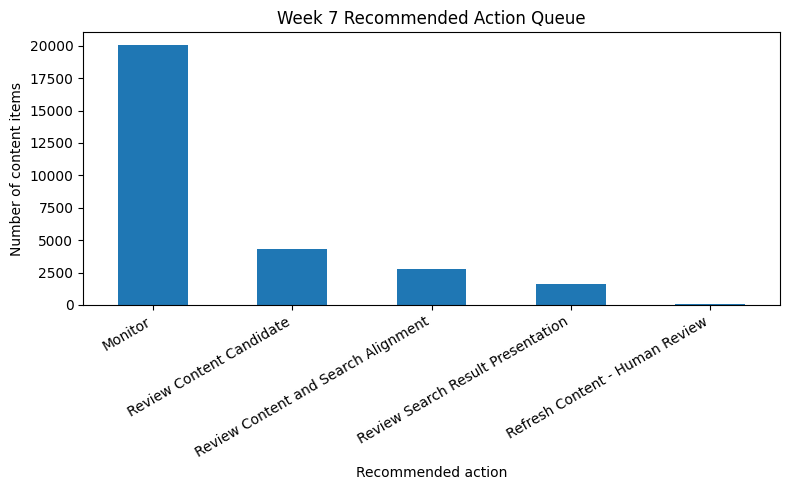

Wrote work/figures/w07_action_queue.png

Export verification:
work/outputs/ranked_action_queue.csv: OK
work/outputs/action_summary.csv: OK
work/outputs/segment_action_map.csv: OK
work/outputs/w07_metrics.json: OK
work/figures/w07_action_queue.png: OK


In [41]:
import json
import os
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Create export directories
# ---------------------------------------------------------

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)


# ---------------------------------------------------------
# 1. Export the ranked action queue
# ---------------------------------------------------------
# This CSV is regenerated by the notebook and should remain
# outside Git according to the repository leak-guard rules.

ranked_queue.to_csv(
    "work/outputs/ranked_action_queue.csv",
    index=False
)

print(
    "Wrote ranked_action_queue.csv:",
    len(ranked_queue),
    "rows"
)


# ---------------------------------------------------------
# 2. Export action summary
# ---------------------------------------------------------

action_summary = (
    ranked_queue["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="count")
)

action_summary.to_csv(
    "work/outputs/action_summary.csv",
    index=False
)

print("Wrote action_summary.csv")


# ---------------------------------------------------------
# 3. Export content-segment → action mapping
# ---------------------------------------------------------

segment_action_map.to_csv(
    "work/outputs/segment_action_map.csv",
    index=False
)

print("Wrote segment_action_map.csv")


# ---------------------------------------------------------
# 4. Export validation and playbook metrics
# ---------------------------------------------------------

metrics_export = {
    "model": "logistic_regression_ctr_underperforming",
    "validation": "client_grouped_stratified_5fold",

    "cv_metrics": {
        key: (
            float(value)
            if isinstance(value, (np.floating, np.integer))
            else value
        )
        for key, value in cv_metrics.items()
    },

    "thresholds": {
        "model_score_top_decile":
            round(float(MODEL_HIGH_THRESHOLD), 4),

        "model_score_top_quartile":
            round(float(MODEL_REVIEW_THRESHOLD), 4),

        "impressions_90d_top_quartile":
            round(float(IMPRESSIONS_HIGH_THRESHOLD), 1),

        "stale_days_since_update": 180
    },

    "queue_summary": {
        "total_rows":
            int(len(ranked_queue)),

        "priority_band_counts": {
            str(key): int(value)
            for key, value in
            ranked_queue["priority_band"]
            .value_counts()
            .sort_index()
            .items()
        },

        "reason_code_counts": {
            str(key): int(value)
            for key, value in
            ranked_queue["reason_code"]
            .value_counts()
            .items()
        }
    },

    "intended_use":
        "Human-reviewed content prioritization and decision-support",

    "causal_claims_supported":
        False
}


with open(
    "work/outputs/w07_metrics.json",
    "w"
) as f:

    json.dump(
        metrics_export,
        f,
        indent=2
    )

print("Wrote w07_metrics.json")


# ---------------------------------------------------------
# 5. Create a reusable figure for the paper
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

action_summary.set_index(
    "recommended_action"
)["count"].plot(
    kind="bar"
)

plt.title(
    "Week 7 Recommended Action Queue"
)

plt.xlabel(
    "Recommended action"
)

plt.ylabel(
    "Number of content items"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "work/figures/w07_action_queue.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Wrote work/figures/w07_action_queue.png")


# ---------------------------------------------------------
# 6. Verify exports
# ---------------------------------------------------------

print("\nExport verification:")

export_files = [
    "work/outputs/ranked_action_queue.csv",
    "work/outputs/action_summary.csv",
    "work/outputs/segment_action_map.csv",
    "work/outputs/w07_metrics.json",
    "work/figures/w07_action_queue.png"
]

for path in export_files:
    print(
        f"{path}:",
        "OK" if os.path.exists(path) else "MISSING"
    )

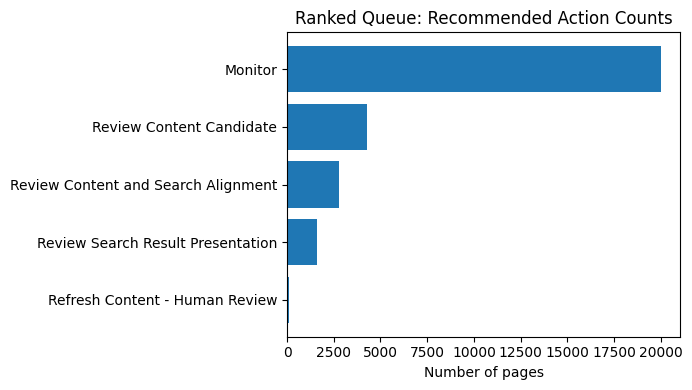

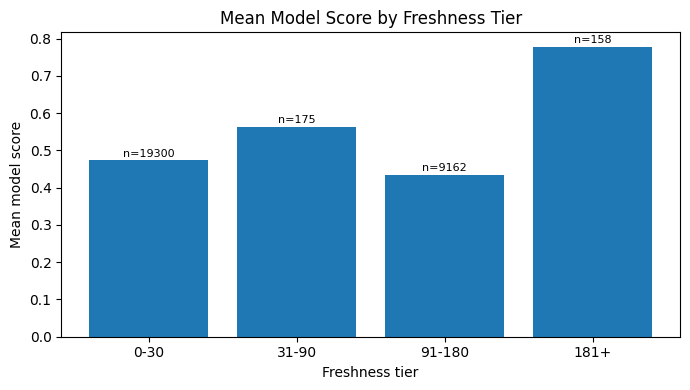

Saved figures:
- work/figures/w07_action_counts.png
- work/figures/w07_decay_insight.png


In [42]:
# ---------------------------------------------------------
# Figure 1: Recommended action counts
# ---------------------------------------------------------

fig1, ax1 = plt.subplots(figsize=(7, 4))

action_order = (
    action_summary
    .sort_values("count", ascending=True)
)

ax1.barh(
    action_order["recommended_action"],
    action_order["count"]
)

ax1.set_xlabel("Number of pages")

ax1.set_title(
    "Ranked Queue: Recommended Action Counts"
)

fig1.tight_layout()

fig1.savefig(
    "work/figures/w07_action_counts.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# Figure 2: Freshness / decay insight
# ---------------------------------------------------------

fig2, ax2 = plt.subplots(figsize=(7, 4))

freshness_order = [
    "0-30",
    "31-90",
    "91-180",
    "181+"
]

freshness_means = (
    decay_view
    .groupby("freshness_tier")["model_score"]
    .mean()
    .reindex(freshness_order)
)

freshness_n = (
    decay_view
    .groupby("freshness_tier")["model_score"]
    .size()
    .reindex(freshness_order)
)

bars = ax2.bar(
    freshness_means.index,
    freshness_means.values
)

for bar, n in zip(
    bars,
    freshness_n.values
):
    if pd.notna(n):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"n={int(n)}",
            ha="center",
            fontsize=8
        )

ax2.set_ylabel("Mean model score")

ax2.set_xlabel(
    "Freshness tier"
)

ax2.set_title(
    "Mean Model Score by Freshness Tier"
)

fig2.tight_layout()

fig2.savefig(
    "work/figures/w07_decay_insight.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved figures:")
print("- work/figures/w07_action_counts.png")
print("- work/figures/w07_decay_insight.png")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.